# Medidas de variabilidad

Aquí revisamos qué tanto varían la edad de primera unión y el número de hijos. También comparamos los grupos que reportaron violencia y los que no.

In [1]:
from pathlib import Path
import sys
import os
import tempfile
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "endireh-matplotlib"))
PROYECTO = Path.cwd().resolve()
if PROYECTO.name == "notebooks":
    PROYECTO = PROYECTO.parent
if str(PROYECTO) not in sys.path:
    sys.path.insert(0, str(PROYECTO))
import polars as pl
from IPython.display import display, Image
from config.rutas import ARCHIVO_ENDIREH_PROCESADO, RUTA_FIGURAS
pl.Config.set_tbl_cols(20)
pl.Config.set_tbl_rows(40)
pl.Config.set_float_precision(4)
df = pl.read_parquet(ARCHIVO_ENDIREH_PROCESADO)
print(f"Registros: {df.height:,}, columnas: {df.width}, Polars {pl.__version__}")


Registros: 105,715, columnas: 31, Polars 1.44.2


## Cálculos

Calculamos el rango, la varianza, la desviación estándar, el CV y el IQR sin ponderar. Para la varianza y la desviación usamos `ddof=1` porque trabajamos con una muestra. El CV se calcula con `scipy.stats.variation` y los cuantiles con Polars.

In [2]:
from src.analysis.medidas_descriptivas import medidas_variabilidad, comparacion_por_violencia
variabilidad = medidas_variabilidad(df)
comparacion = comparacion_por_violencia(df)
display(variabilidad)
display(comparacion)

variable,n_validos,minimo,maximo,rango,varianza_muestral,desviacion_estandar,coeficiente_variacion_pct,iqr
str,i64,f64,f64,f64,f64,f64,f64,f64
"""edad_primer_union""",9951,9.0000,76.0000,67.0000,94.0213,9.6965,48.5616,13.0000
"""num_hijos""",105715,0.0000,4.0000,4.0000,2.1002,1.4492,70.3602,2.0000


variable,reporto_violencia,n_validos,media_simple,media_ponderada,mediana,rango,varianza_muestral,desviacion_estandar,coeficiente_variacion_pct,iqr
str,str,i64,f64,f64,f64,f64,f64,f64,f64,f64
"""edad_primer_union""","""No""",6365,20.1027,19.9509,18.0000,67.0000,96.7160,9.8344,48.9208,13.0000
"""edad_primer_union""","""Sí""",3586,19.7270,19.3554,18.0000,63.0000,89.1737,9.4432,47.8693,13.0000
"""num_hijos""","""No""",86516,2.0140,1.7954,3.0000,4.0000,2.1462,1.4650,72.7406,2.0000
"""num_hijos""","""Sí""",19199,2.2657,2.1232,3.0000,4.0000,1.8413,1.3570,59.8904,2.0000


## Interpretación

**edad_primer_union**: rango 67, varianza muestral 94.02, desviación estándar 9.70, CV 48.56% e IQR 13.

**num_hijos**: rango 4, varianza muestral 2.10, desviación estándar 1.45, CV 70.36% e IQR 2.

In [3]:
from src.visualization.eda import configurar_estilo, grafica_edad_por_violencia
configurar_estilo()
grafica_edad_por_violencia(df)

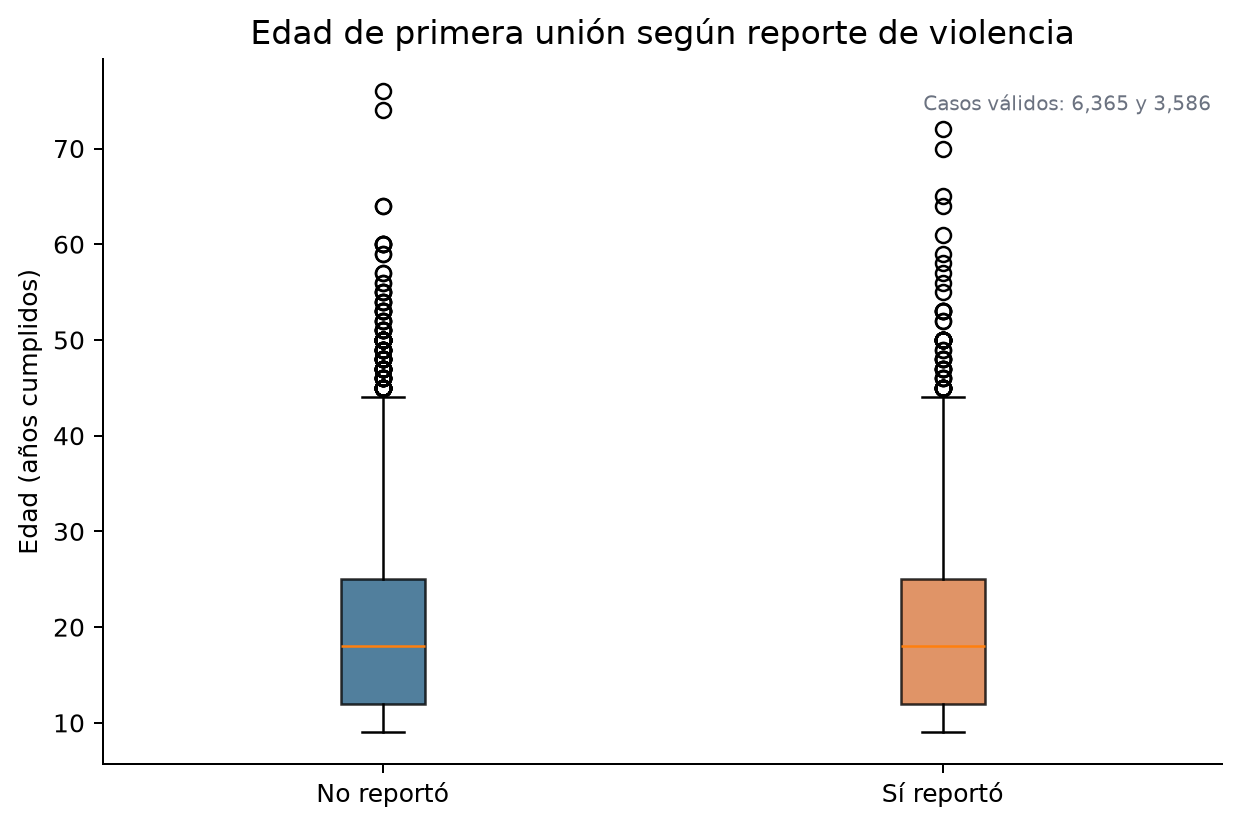

In [4]:
for nombre in ['05_edad_por_violencia.png']:
    display(Image(filename=RUTA_FIGURAS / nombre, width=850))

Los dos grupos tienen una mediana de edad de 18 años y un IQR de 13. El CV es 48.92% en quienes no reportaron violencia y 47.87% en quienes sí. Los boxplots muestran una dispersión parecida. Con estos resultados no podemos decir que la edad cause o prevenga la violencia. También hay que tomar en cuenta que faltan muchos datos de edad.